In [1]:
import xarray as xr
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
# Data is stored in gb02, with separate directories for REZ and capital city data.
# Each file contains the full time period from August 2015 to the end of 2025 for a single region
data_dir = Path('/g/data/gb02/cd3022/solar-pv/')
rez_files = [f for f in data_dir.glob('REZ/*.nc')]
city_files = [f for f in data_dir.glob('GCCSA/*.nc')]

In [3]:
# Each file contains idential coords and dims, so we can't use xr.open_mfdataset() as it won't know
# how to join the data.
# Instead, we open the files one by one (there are 36 in total so this doesn't take too long). As the files
# are being opened, retrive the region name from the file name and then add it as a "region" coordinate. Then
# once all files have been opened and have the region added as a coordinate, we can concat the datasets.

# list to store datasets
ds_list = []
for file in rez_files:
    # retrieve REZ name from the file name
    rez_name = file.stem[0:2]

    # open the netcdf file
    ds = xr.open_dataset(file)

    # assign the REZ name as a coordinate
    ds = ds.assign_coords({'region': rez_name})

    # add to dataset list
    ds_list.append(ds)

# exactly the same as above, but for the capital cities
for file in city_files:
    city_name = file.stem[1:5]
    
    ds = xr.open_dataset(file)
    ds = ds.assign_coords({'region': city_name})
    
    ds_list.append(ds)

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.11/lib/python3.11/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'kerchunk' loading failed:
No module named 'zarr.core.array_spec'; 'zarr.core' is not a package
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


In [4]:
# Now combine into a single dataset, using the new "region" coordinate as the concat dim
ds = xr.concat(
    ds_list,
    dim='region',
    coords='minimal',
    compat='override',
    join='outer',
)

In [5]:
# Change times to AEST (timezone used by AEMO)
time_utc = pd.to_datetime(ds.time.values)
time_aest = time_utc.tz_localize("UTC").tz_convert("Australia/Brisbane")
time_aest_naive = time_aest.tz_convert("Australia/Brisbane").tz_localize(None)
ds = ds.assign_coords(time=("time", time_aest_naive))

# The satellite undergoes maintenance and skips a timestep once a day, so remove this time
ds = ds.where(ds['time'].dt.strftime('%H:%M') != '12:40', drop=True)

In [6]:
# Add CSI as a variable, by taking the ratio between the "actual" and "ideal" variables
# see /g/data/gb02/cd3022/solar-pv/README.md for more details
ds['csi'] = ds['actual'] / ds['ideal'] 

# Where CSI is great than 1, flatten values to 1.
# Because CSI >= 1 indicates a clear sky, and large values can distort the norm
ds['csi'] = xr.where(ds.csi > 1, 1, ds.csi)

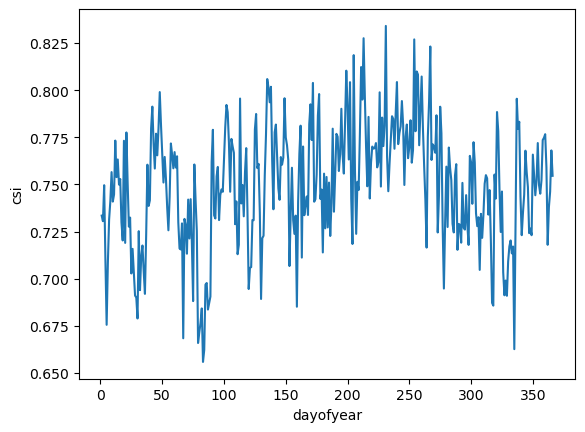

In [7]:
# Now that we have all the data laoded, here are some ways we can use it

# Annual mean national CSI:
ds.csi.groupby("time.dayofyear").mean().mean("region").plot()

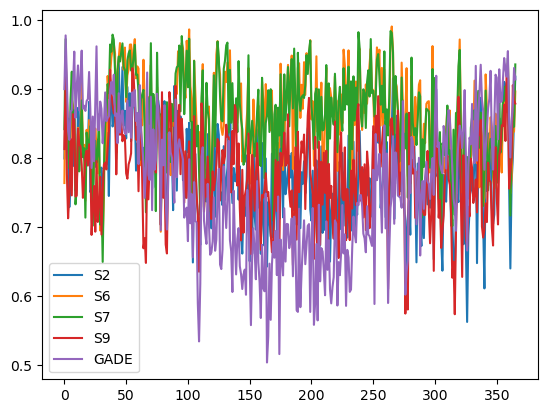

In [10]:
# Annual mean CSI for specific regions (e.g. the SA regions):

# Probably a better way of selecting by state, but given the small number of regions this rudimentary method is fine
regions = [
    'S2',
    'S6',
    'S7',
    'S9',
    'GADE'
]

plt.figure()
for reg in regions:
    csi = ds.sel(region=reg).csi
    mean_daily_csi = csi.groupby("time.dayofyear").mean()
    plt.plot(mean_daily_csi, label=reg)
plt.legend()

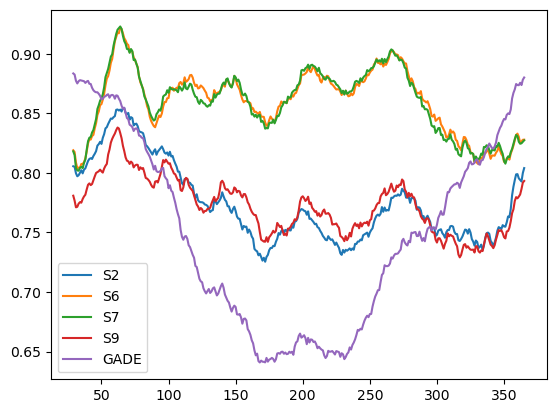

In [31]:
# Same as above, but using a running mean to smooth data
regions = [
    'S2',
    'S6',
    'S7',
    'S9',
    'GADE'
]

plt.figure()
for reg in regions:
    csi = ds.sel(region=reg).csi
    mean_daily_csi = csi.groupby("time.dayofyear").mean()
    smoothed_mean_daily_csi = mean_daily_csi.rolling(dayofyear=30).mean()
    plt.plot(smoothed_mean_daily_csi, label=reg)
plt.legend()

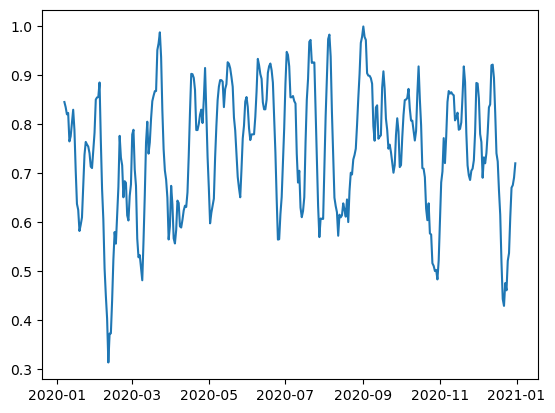

In [28]:
# Daily CSI for a single region and year
region = 'N3'
year = '2020'
csi = ds.sel(region=region, time=year).csi
daily_csi = csi.resample(time='1D').mean()
smoothed_daily_csi = daily_csi.rolling(time=7).mean()
plt.plot(smoothed_daily_csi.time, smoothed_daily_csi)